## Imports

In [1]:
import os
import sys
from pathlib import Path
import ipynbname

import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

from gvxrPython3 import gvxr
from gvxrPython3.JSON2gVXRDataReader import *
import tifffile as tiff
from skimage.filters import threshold_otsu

xsim_root = ipynbname.path().parent.parent
sys.path.append(str(xsim_root))

#own class imports
from ML.tomograph import Tomograph



c:\Users\SEFAHLGRENK\AppData\Local\miniconda3\envs\dev_env\Lib\site-packages\dxchange\__init__.py:63: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# DEFINE SCANNING PARAMETERS 
"--geometry-- (dont change)"
SDD = 20.42 
SSD = 11-3
xPixels = 996            
yPixels = 996            
pixel_size = 0.00135       #effective pixel size

"--source--"
voltage_kV = 70          
current_mA = 1  
exposure_time_s =8
filter_thickness = 0.5

"--detector"
epsilon = 0.015           # 0.01 - 0.02 (defines amount of blur)

"--sample--"            
density = 1.52
offset = (0,0,0)         
rotation =(-60,0,0)  

nbr_projections = 1300
reconstruction_filter="shepp-logan"
FFC = 0 

mag = SDD/SSD
voxel_size = pixel_size/mag
print(mag)
print(voxel_size)


2.5525
0.0005288932419196865


In [3]:
xct = Tomograph()
xct.set_geometry(SSD=SSD, SDD=SDD, xPixels=xPixels, yPixels=yPixels, pixel_size=pixel_size)
xct.setup_poly_spectrum(voltage_kV=voltage_kV, current_mA=current_mA, 
                                  exposure_time_s=exposure_time_s, filter_tickness=filter_thickness, th_deg=12)
xct.setup_detector(shot_noise=True, epsilon=epsilon)

s = sp.Spek(kvp= 70 , th= 12 , mas= 8 , z= 2.0420000076293947
16512478033486.14  photons / cm^2
300939.94861675776  photons / pixel


In [4]:
meshes_root = xsim_root / "Data/Cotton fibre/Meshes/"
folder = Path(str(meshes_root) + "/cotton_fibres_moved")      
files = folder.glob(f"{"fibre"}_*.stl")
meshes = [str(f) for f in files]
cotton_mix = ["C", "H", "O"]
cotton_wf = [0.444, 0.062, 0.494]
    
i = 1
for mesh in meshes:
        xct.addMesh(f"fibre_{i}", mesh, density=density, mixture=cotton_mix, mass_fraction=cotton_wf, unit="um")

        dx, dy, dz = rotation
        gvxr.rotateNode(
                f"fibre_{i}", dx,dy,dz)
            
        gx, gy, gz = offset
        if gx != 0 or gy != 0 or gz != 0:
            gvxr.translateNode(f"fibre_{i}", gx, gy, gz, "um")
        i += 1


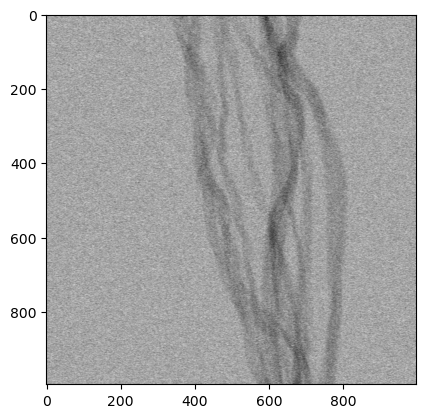

In [5]:
img = xct.compute2D()
plt.figure()
plt.imshow(img, cmap='gray')
plt.show()